In [1]:
import numpy as np
import qutip as qt
from RCP import *
from tqdm import tqdm
import pickle
from entropy import RDM_entropy
import random as rand

N=12
d=2**N

analog_model=[]
exact_model = Quantum_dot(1e9)
analog_model.append(analog_QD(exact_model, h=5e4,J=1e5, DeltaE=2e8,epsilon=0.001)) #theta represents tan(theta) in the paper
exact_model2 = Quantum_dot(1e9,N=12,a=[0.1735, 0.1438, 0.0625, -0.0427, -0.0606, 0.0207],phi=[0.0013, 0.0049, -0.0139, -0.0093, 0.0062])
analog_model.append(analog_QD(exact_model2, h=5e4,J=1e5, DeltaE=2e8,epsilon=0.001))
exact_model3 = Quantum_dot(1e9,N=12,a=[0.1522, 0.1288, 0.0434, -0.0866, -0.0375, -0.0174],phi=[0.0093, -0.0431, 0.0567, -0.0104, -0.0313])
analog_model.append(analog_QD(exact_model3, h=5e4,J=1e5, DeltaE=2e8,epsilon=0.001))

def rank_k_haar_state(rank,seed=None):
    #initial qutip state
    state=qt.tensor(qt.rand_ket([2]*2,seed = seed),qt.rand_ket([2]*8,seed = seed))
    for _ in range(rank-1):
    #subsystems with 2 & 8 qubits
        state+=qt.tensor(qt.rand_ket([2]*2,seed = seed),qt.rand_ket([2]*8,seed = seed))
    return state.unit() #normalization

def rank_k_state(rank,seed=None):
    rand.seed(seed)
    result = qt.Qobj(np.zeros((d,1)), dims=[[2]*10, [1]])
    for _ in range(rank):
    #initial qutip state
        state = qt.basis([2]*10)
        #implement a random pauli operator on each qubit
        pauli_ops = [qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()]
        op = qt.tensor([rand.choice(pauli_ops) for _ in range(10)])
        state = op * state
        result += state
    return result.unit() #normalization
def computation_basis_state(num_qubits):
    #retrun a list of all computational basis states for num_qubits qubits, represented as integers lists
    basis_states = []
    for i in range(2**num_qubits):
        bin_str = format(i, '0' + str(num_qubits) + 'b')
        basis_states.append([int(bit) for bit in bin_str])
    return basis_states

def thermal_state(temperature):
    basis = computation_basis_state(5)
    computation_basis = [basis[i]+basis[i] for i in range(len(basis))]
    H=qt.Qobj(np.zeros((d,d)), dims=[[2]*N]*2)
    for i in range(10):
        H-=qt.tensor([qt.sigmaz() if j == i else qt.qeye(2) for j in range(N)])
    # psi_T = qt.Qobj(np.zeros(d), dims=[2]*10)
    psi_T = qt.Qobj(np.zeros((d,1)), dims=[[2]*N, [1]])
    coef=[0,1,-1,0]
    for i,A_subsys in enumerate(computation_basis):
        
        # psi_T += qt.tensor(qt.basis([2]*4,A_subsys),qt.basis([2]*6))*np.exp(-coef[i]*temperature)
        psi_T += qt.tensor(qt.basis([2]*10,A_subsys),qt.basis([2]*2))
    # Calculate the thermal state using the Gibbs distribution
    psi_T = (-H * temperature).expm()*psi_T
    # Normalize the density matrix
    return psi_T.unit()

def analog_error(initial_state, analog_model,time):
    # Compute the error between the initial state and the analog model
    error_norms = []
    for model in analog_model:
        exact_states=qt.mesolve(model.exact_model.H,initial_state, time).states
        analog_states=qt.mesolve(model.H,initial_state, time).states
        errors = exact_states[-1]-analog_states[-1]
        error_norms.append(errors.norm('l2'))
    return error_norms

seed=123

entropy_list = []
error_list = []
# initial_state = qt.rand_ket([2]*10,seed = 123)
# initial_state = qt.basis([2]*10)
for temperature in tqdm(range(60)):
    state = thermal_state((temperature)*0.008)
    entropy_list.append(RDM_entropy(state.full(),7,qubits=12)[-1]) #entropy of 8-qubit subsystem
    error_list.append(analog_error(state,analog_model,np.linspace(0,1.8e-7 , 2)))

100%|██████████| 60/60 [00:58<00:00,  1.02it/s]


In [2]:
bound=[]
for model in analog_model:
    perturbation=model.H-model.exact_model.H
    summator=0
    for i in tqdm(range(500)):
        summator+=3.6e-10*np.linalg.norm(perturbation(3.6e-10*i).full(),'fro')/sqrt(d)
            # summator+=5e-11*np.linalg.norm(perturbation(2.5e-8*i+5e-11*j).full(),'fro')**2/d
    bound.append(summator)

100%|██████████| 500/500 [00:23<00:00, 21.36it/s]


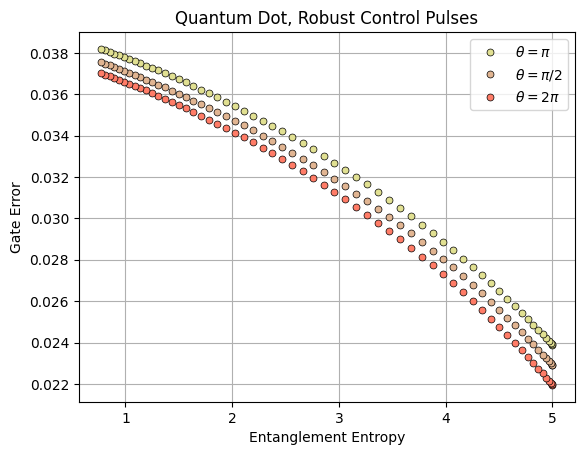

In [3]:
import matplotlib.pyplot as plt
temper=[(0.008*temp) for temp in range(1,60)]
plt.plot(entropy_list,np.array(error_list)[:,0],color='0.3', marker='o', markersize=5, mfc="#e1e092", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\pi$')
plt.plot(entropy_list,np.array(error_list)[:,1],color='0.3', marker='o', markersize=5, mfc="#e1b592", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\pi/2$')
plt.plot(entropy_list,np.array(error_list)[:,2],color='0.3', marker='o', markersize=5, mfc="#ff7c67", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=2\pi$')

# plt.plot(entropy_list,[bound[0]]*60,color='#e1e092', linestyle='-.', label='bound: θ=π',linewidth=2)
# plt.plot(entropy_list,[bound[1]]*60,color='#e1b592', linestyle='-.', label='bound: θ=π/2',linewidth=2)
# plt.plot(entropy_list,[bound[2]]*60,color='#ff7c67', linestyle='-.', label='bound: θ=2π',linewidth=2)
# plt.plot(temper,np.array(error_list)[1:,0],color='0.3', marker='o', markersize=5, mfc="#e1e092", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\pi$')
# plt.plot(temper,np.array(error_list)[1:,1],color='0.3', marker='o', markersize=5, mfc="#e1b592", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=\pi/2$')
# plt.plot(temper,np.array(error_list)[1:,2],color='0.3', marker='o', markersize=5, mfc="#ff7c67", mec='k', linestyle='', markeredgewidth=0.5,label=r'$\theta=2\pi$')

# plt.plot(temper,[bound[0]]*59,color='#e1e092', linestyle='-.', label='bound: θ=π',linewidth=2)
# plt.plot(temper,[bound[1]]*59,color='#e1b592', linestyle='-.', label='bound: θ=π/2',linewidth=2)
# plt.plot(temper,[bound[2]]*59,color='#ff7c67', linestyle='-.', label='bound: θ=2π',linewidth=2)


plt.xlabel('Entanglement Entropy')
# plt.xlabel(r'Temperature$^{-1}$')
plt.ylabel('Gate Error')
plt.title('Quantum Dot, Robust Control Pulses')
plt.legend(loc=0)
plt.grid()
plt.savefig('./Figures/RCP_temperature_error.pdf',bbox_inches='tight',dpi=600)
plt.show()

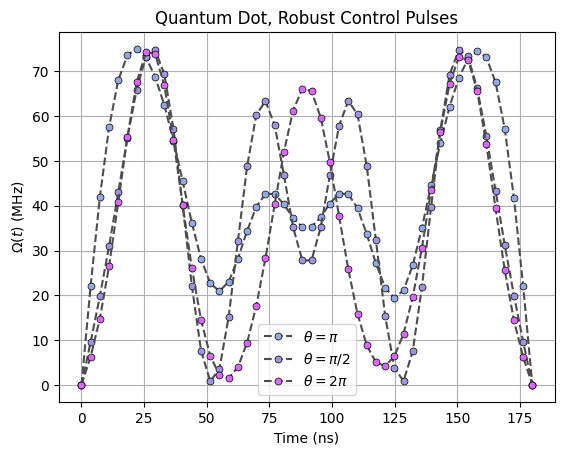

In [4]:
#RCP plotting
time = np.linspace(0,180 , 50)
driving_strengths=[]
for model in analog_model:
    driving_strengths.append([])
    for t in time:
        driving_strengths[-1].append(model.Omega*model.time_dependent_Omega(t*1e-9)/2e6) #in MHz

plt.plot(time,driving_strengths[0],color='0.3', marker='o', markersize=5, mfc="#92aae1", mec='k', linestyle='--', markeredgewidth=0.5,label=r'$\theta=\pi$')
plt.plot(time,driving_strengths[1],color='0.3', marker='o', markersize=5, mfc="#a292e1", mec='k', linestyle='--', markeredgewidth=0.5,label=r'$\theta=\pi/2$')
plt.plot(time,driving_strengths[2],color='0.3', marker='o', markersize=5, mfc="#dc67ff", mec='k', linestyle='--', markeredgewidth=0.5,label=r'$\theta=2\pi$')
plt.xlabel('Time (ns)')
plt.ylabel(r'$\Omega(t)$ (MHz)')
plt.title('Quantum Dot, Robust Control Pulses')
plt.legend(loc=0)
plt.grid()
plt.savefig('./Figures/RCP_driving_pulses.pdf',bbox_inches='tight',dpi=600)